In [2]:
import pandas as pd
import numpy as np

# Step 1: Create raw DataFrame
data = {
    "employee_id": [101, 102, 103, 104, 105, 102, 106, 107, 108, 109],
    "name": [
        "Alice Johnson",
        "bob smith",
        "Charlie Brown",
        "Diana",
        "Eve Adams",
        "bob smith",
        "Frank ",
        " Grace Lee",
        "Hank",
        "Ivy Clarke",
    ],
    "department": [
        "HR",
        "IT",
        "Finance",
        "hr",
        "IT",
        "IT",
        "FINANCE",
        "HR",
        None,
        "Finance",
    ],
    "age": [29, 34, 45, 27, None, 34, 300, 38, 25, 31],
    "salary": [
        "$52,000",
        "$78,000",
        "$91,000",
        "$48,500",
        "$85,000",
        "$78,000",
        "$102,000",
        "$67,000",
        "$54,000",
        None,
    ],
    "join_date": [
        "2021-03-15",
        "2019-07-22",
        "2018-01-10",
        "2022-11-05",
        "2020-06-30",
        "2019-07-22",
        "2017-09-01",
        "2023-02-14",
        "2021-08-19",
        "2022-04-03",
    ],
    "rating": [4.2, 3.8, 4.5, None, 4.0, 3.8, 4.1, 3.5, None, 4.3],
}

df = pd.DataFrame(data)

# Step 2: Inspect raw data
print("Raw DataFrame:\n", df.head())
print("DataFrame Info:", df.info())
print("DataFrame Description:", df.describe())
print("DataFrame Description (all):", df.describe(include="all"))

Raw DataFrame:
    employee_id           name department   age   salary   join_date  rating
0          101  Alice Johnson         HR  29.0  $52,000  2021-03-15     4.2
1          102      bob smith         IT  34.0  $78,000  2019-07-22     3.8
2          103  Charlie Brown    Finance  45.0  $91,000  2018-01-10     4.5
3          104          Diana         hr  27.0  $48,500  2022-11-05     NaN
4          105      Eve Adams         IT   NaN  $85,000  2020-06-30     4.0
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   employee_id  10 non-null     int64  
 1   name         10 non-null     str    
 2   department   9 non-null      str    
 3   age          9 non-null      float64
 4   salary       9 non-null      str    
 5   join_date    10 non-null     str    
 6   rating       8 non-null      float64
dtypes: float64(2), int64(1), str(4)
memory usage: 692.0 byt

In [3]:
# Clean names: strip spaces, title case
df["name"] = df["name"].str.strip().str.title()

# Standardize department names
df["department"] = df["department"].str.strip().str.upper()

# Fix invalid ages (remove unrealistic values)
df.loc[df["age"] > 100, "age"] = np.nan

# Convert salary to numeric
df["salary"] = df["salary"].str.replace(r"[$,]", "", regex=True).astype(float)

# Convert join_date to datetime
df["join_date"] = pd.to_datetime(df["join_date"])

# Drop duplicate rows (same employee_id + name)
df = df.drop_duplicates(subset=["employee_id", "name"])

In [4]:
# Summary by department
dept_summary = df.groupby("department")[["salary", "age", "rating"]].mean()

# Count employees per department
dept_counts = df["department"].value_counts()

# Highest paid employee
highest_paid = df.loc[df["salary"].idxmax()]

print(dept_summary)
print(dept_counts)
print("Highest paid employee:", highest_paid["name"], highest_paid["salary"])

                  salary        age  rating
department                                 
FINANCE     96500.000000  38.000000    4.30
HR          55833.333333  31.333333    3.85
IT          81500.000000  34.000000    3.90
department
HR         3
FINANCE    3
IT         2
Name: count, dtype: int64
Highest paid employee: Frank 102000.0


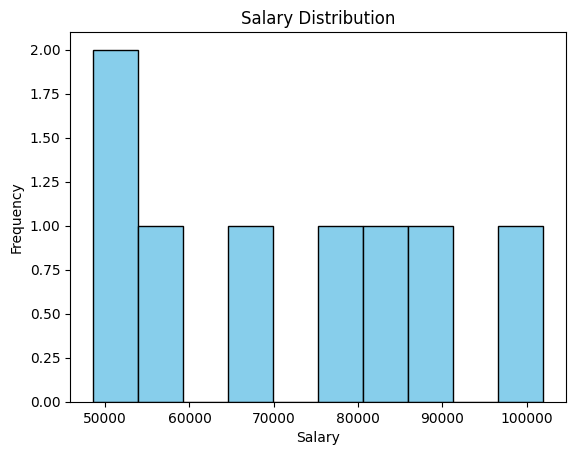

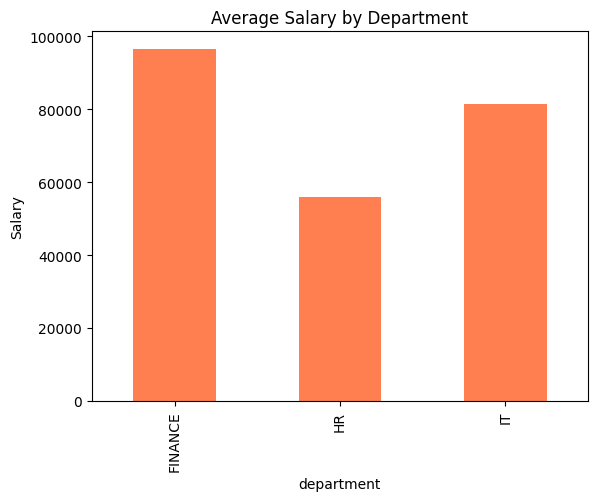

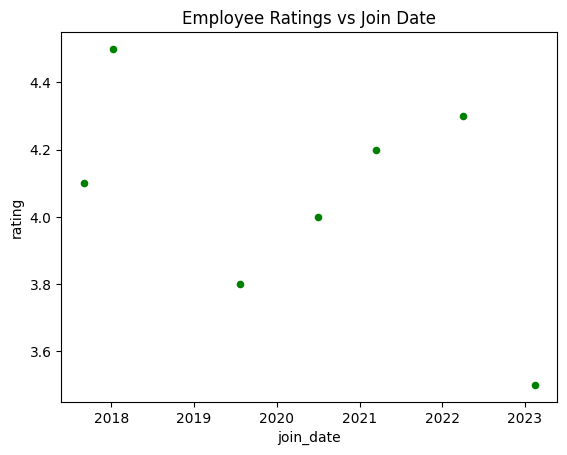

In [5]:
import matplotlib.pyplot as plt

# Salary distribution
df["salary"].plot(kind="hist", bins=10, color="skyblue", edgecolor="black")
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.show()

# Average salary by department
dept_summary["salary"].plot(kind="bar", color="coral")
plt.title("Average Salary by Department")
plt.ylabel("Salary")
plt.show()

# Ratings over time
df.plot(x="join_date", y="rating", kind="scatter", color="green")
plt.title("Employee Ratings vs Join Date")
plt.show()

In [6]:
print(df)
pd.set_option("display.max_rows", None)  # show all rows
pd.set_option("display.max_columns", None)  # show all columns
pd.set_option("display.width", None)  # don't wrap lines
pd.set_option("display.max_colwidth", None)  # show full column content

print(df)

   employee_id           name department   age    salary  join_date  rating
0          101  Alice Johnson         HR  29.0   52000.0 2021-03-15     4.2
1          102      Bob Smith         IT  34.0   78000.0 2019-07-22     3.8
2          103  Charlie Brown    FINANCE  45.0   91000.0 2018-01-10     4.5
3          104          Diana         HR  27.0   48500.0 2022-11-05     NaN
4          105      Eve Adams         IT   NaN   85000.0 2020-06-30     4.0
6          106          Frank    FINANCE   NaN  102000.0 2017-09-01     4.1
7          107      Grace Lee         HR  38.0   67000.0 2023-02-14     3.5
8          108           Hank        NaN  25.0   54000.0 2021-08-19     NaN
9          109     Ivy Clarke    FINANCE  31.0       NaN 2022-04-03     4.3
   employee_id           name department   age    salary  join_date  rating
0          101  Alice Johnson         HR  29.0   52000.0 2021-03-15     4.2
1          102      Bob Smith         IT  34.0   78000.0 2019-07-22     3.8
2          1

In [7]:
print(df.to_string())
df
#df.sample(10)
df.tail(10)
df.info()

   employee_id           name department   age    salary  join_date  rating
0          101  Alice Johnson         HR  29.0   52000.0 2021-03-15     4.2
1          102      Bob Smith         IT  34.0   78000.0 2019-07-22     3.8
2          103  Charlie Brown    FINANCE  45.0   91000.0 2018-01-10     4.5
3          104          Diana         HR  27.0   48500.0 2022-11-05     NaN
4          105      Eve Adams         IT   NaN   85000.0 2020-06-30     4.0
6          106          Frank    FINANCE   NaN  102000.0 2017-09-01     4.1
7          107      Grace Lee         HR  38.0   67000.0 2023-02-14     3.5
8          108           Hank        NaN  25.0   54000.0 2021-08-19     NaN
9          109     Ivy Clarke    FINANCE  31.0       NaN 2022-04-03     4.3
<class 'pandas.DataFrame'>
Index: 9 entries, 0 to 9
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   employee_id  9 non-null      int64         
 1   name